# Task 2A: Use case and dataset engineering
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/krishanSKDA/CDAZZDEV-MLE-Krishan_Danushka/blob/main/task2_genai/Task2_Data.ipynb)

Runs on CPU. Secrets are read by `common/config.py` from **Colab Secrets** (key icon in the sidebar) or a local `.env`. Nothing is hardcoded.

## Problem statement: material risk-factor extraction from financial disclosures

**Input.** A passage from a corporate disclosure (10-K risk factors, 10-Q MD&A, earnings-call remarks or Q&A, 8-K, bond or IPO prospectus, CEO letter, investor-day transcript, sustainability report) plus its document type.

**Output.** JSON only:
`{"risks": [{"category", "severity", "affected_metric", "evidence_quote"}], "overall_risk_level"}`
with `category` from a fixed 12-class taxonomy, `severity` ∈ {low, medium, high}, at most one entry per category, `evidence_quote` copied verbatim from the passage, and `overall_risk_level` = max severity or `none`.

**Correct.** Valid schema JSON; the category set equals the reference; every evidence quote is a verbatim span of the passage; severities within one level of the reference.
**Partially correct.** Valid and grounded, but categories missed/extra, a severity off by two levels, or JSON that does not parse.
**Hallucinated.** Any evidence quote that does not appear in the passage (a fabricated risk or fabricated support).

**Why it is non-trivial.** Multi-label classification over 12 classes, severity calibration, span extraction that must be verbatim, and *distractor* sentences describing resolved/immaterial issues that must be ignored. Groundedness is machine-checkable, which makes hallucination measurable.

In [1]:
import os, sys, subprocess

REPO_URL = "https://github.com/krishanSKDA/CDAZZDEV-MLE-Krishan_Danushka.git"
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "/content/repo"], check=True)
    os.chdir("/content/repo")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    while not os.path.exists("requirements.txt"):
        os.chdir("..")
sys.path.insert(0, os.getcwd())
print("repo root:", os.getcwd(), "| colab:", IN_COLAB)

repo root: d:\My-Project\SML-task | colab: False


## Teacher model and full system prompt
Primary teacher: Google **gemini-3.1-flash-lite** (cheapest free-tier Gemini text model); Override with `TEACHER_MODELS`; generation is resumable if the daily free-tier cap is reached. Weak teacher outputs are filtered by validation. The student is **Qwen2.5-3B-Instruct**, a different model family, so teacher ≠ student.

In [2]:
from task2_genai.data_generation.teacher_prompt import TEACHER_SYSTEM_PROMPT, TEACHER_USER_TEMPLATE
print(TEACHER_SYSTEM_PROMPT)
print("\nUSER TEMPLATE:\n" + TEACHER_USER_TEMPLATE)

You generate training data for a model that extracts MATERIAL risk factors from corporate financial disclosures.

Given a JSON specification, write ONE realistic disclosure passage and its gold-standard extraction.

PASSAGE REQUIREMENTS
- Use the fictional company name given. Never mention real companies.
- Match the sector, document type and writing style requested; the word count must fall inside the requested range.
- Embed a material risk for EXACTLY the requested categories (zero categories = a passage with no material risk, e.g. results commentary or mitigated issues). Express each risk naturally; never write the category label itself.
- If "distractor" is true, add one sentence about an issue that is explicitly resolved, immaterial or fully mitigated. It must NOT appear in the extraction.
- Use concrete details where natural: percentages, amounts, dates, regions, counterparties.

EXTRACTION REQUIREMENTS
- One entry per requested category, in order of first appearance in the pass

### Seed grid for diversity
15 sectors × 10 document types × 4 writing styles × 3 length buckets × 0 to 4 risks (least-used categories drawn first) × optional distractor sentence.

In [3]:
import json
from task2_genai.data_generation.generate import make_specs
print(json.dumps(make_specs(3), indent=1))

[
 {
  "id": "ex_0000",
  "company": "Westmere Partners",
  "sector": "apparel retail",
  "doc_type": "investor day transcript",
  "style": "hedged forward-looking language",
  "length_bucket": "short",
  "word_range": [
   60,
   110
  ],
  "risk_categories": [
   "supply_chain",
   "geopolitical",
   "key_personnel"
  ],
  "distractor": true
 },
 {
  "id": "ex_0001",
  "company": "Tidewell Industries",
  "sector": "consumer packaged foods",
  "doc_type": "earnings call analyst Q&A answer",
  "style": "dense legal boilerplate",
  "length_bucket": "long",
  "word_range": [
   220,
   320
  ],
  "risk_categories": [
   "competition"
  ],
  "distractor": false
 },
 {
  "id": "ex_0002",
  "company": "Fenwick Corporation",
  "sector": "clinical-stage biotech",
  "doc_type": "investor day transcript",
  "style": "numbers-heavy analytical prose",
  "length_bucket": "long",
  "word_range": [
   220,
   320
  ],
  "risk_categories": [
   "cybersecurity_operational",
   "liquidity_debt",
   "cu

### Generate (resumable)
Accepted examples are appended to `raw.jsonl`, rejections (with reason) to `rejected.jsonl`. Re-running continues where it stopped. Each example is validated: requested categories only, verbatim quotes, length range, and consistent overall level.

In [4]:
import os
from task2_genai.data_generation import generate as gen

TARGET = 320
have = len(gen._read_ids(gen.RAW_PATH))
print("already accepted:", have)
if have < TARGET:
    gen.generate(TARGET, max_specs=600, teachers=os.getenv("TEACHER_MODELS", gen.DEFAULT_TEACHERS).split(","))
print("accepted:", len(gen._read_ids(gen.RAW_PATH)), "| rejected:", len(gen._read_ids(gen.REJECTED_PATH)))

already accepted: 0
{"ts": "2026-10-06T09:21:41+00:00", "level": "INFO", "logger": "task2.generate", "msg": "accepted", "data": {"id": "ex_0000", "accepted": 1, "teacher": "gemini:gemini-3.1-flash-lite"}}
{"ts": "2026-10-06T09:21:44+00:00", "level": "INFO", "logger": "task2.generate", "msg": "accepted", "data": {"id": "ex_0001", "accepted": 2, "teacher": "gemini:gemini-3.1-flash-lite"}}
{"ts": "2026-10-06T09:21:47+00:00", "level": "INFO", "logger": "task2.generate", "msg": "accepted", "data": {"id": "ex_0002", "accepted": 3, "teacher": "gemini:gemini-3.1-flash-lite"}}
{"ts": "2026-10-06T09:21:50+00:00", "level": "INFO", "logger": "task2.generate", "msg": "accepted", "data": {"id": "ex_0003", "accepted": 4, "teacher": "gemini:gemini-3.1-flash-lite"}}
{"ts": "2026-10-06T09:21:53+00:00", "level": "INFO", "logger": "task2.generate", "msg": "accepted", "data": {"id": "ex_0004", "accepted": 5, "teacher": "gemini:gemini-3.1-flash-lite"}}
{"ts": "2026-10-06T09:21:56+00:00", "level": "INFO", "l

In [5]:
import pandas as pd
from task2_genai.dataset import load_jsonl
rej = pd.DataFrame(load_jsonl(gen.REJECTED_PATH)) if gen.REJECTED_PATH.exists() else pd.DataFrame(columns=["reason"])
acc = len(gen._read_ids(gen.RAW_PATH))
print(f"acceptance rate: {acc / max(acc + len(rej), 1):.1%}")
rej["reason"].str.split(" ").str[:3].str.join(" ").value_counts()

acceptance rate: 97.6%


reason
evidence_quote not verbatim    8
Name: count, dtype: int64

## Clean, format with the Qwen chat template, split 80/10/10

In [6]:
from transformers import AutoTokenizer
from task2_genai.dataset import build_dataset

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
build = build_dataset(gen.RAW_PATH, tokenizer)
print("raw:", build["raw"], "| after near-duplicate removal:", build["after_dedup"])
print("near-duplicates dropped (id, duplicate_of, cosine):", build["near_duplicates_dropped"])
print("SPLIT SIZES:", build["split_sizes"])

d:\My-Project\SML-task\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


raw: 320 | after near-duplicate removal: 320
near-duplicates dropped (id, duplicate_of, cosine): []
SPLIT SIZES: {'train': 256, 'val': 32, 'test': 32}


In [7]:
from task2_genai.dataset import DATA_DIR
train = load_jsonl(DATA_DIR / "train.jsonl")
print(train[0]["text"])

<|im_start|>system
You are a financial risk analyst. Extract the MATERIAL risk factors from the disclosure excerpt.
Categories: supply_chain (supplier concentration, component shortages, logistics disruption, manufacturing capacity); regulatory_legal (regulation, litigation, export controls, antitrust, compliance failures); competition (competitive or pricing pressure, market-share loss, new entrants); customer_concentration (dependence on a few customers, distributors or channels); macroeconomic (demand cyclicality, recession, inflation, consumer or enterprise spending); fx_interest_rate (currency translation, interest-rate exposure, hedging costs); liquidity_debt (leverage, covenants, refinancing, cash burn, going-concern doubt); cybersecurity_operational (cyber incidents, IT outages, operational failures, recalls); geopolitical (trade tensions, tariffs, sanctions, conflict, country risk); technology_ip (technology obsolescence, IP disputes, R&D or product-transition execution); esg_

## Diversity analysis

In [8]:
from task2_genai.dataset import diversity_report, summary_frame
clean = load_jsonl(DATA_DIR / "clean.jsonl")
report = diversity_report(clean)
print(json.dumps({k: v for k, v in report.items() if k != "top_keywords"}, indent=1))

{
 "n_examples": 320,
 "passage_words": {
  "min": 69,
  "p25": 100.0,
  "median": 159.0,
  "p75": 239.25,
  "max": 282,
  "mean": 167.809375
 },
 "pairwise_tfidf_cosine": {
  "mean": 0.022897025163128408,
  "p95": 0.048420675190274674,
  "max": 0.15566903916534588
 },
 "distinct_1": 0.1053,
 "distinct_2": 0.5018,
 "category_counts": {
  "supply_chain": 56,
  "competition": 56,
  "technology_ip": 56,
  "fx_interest_rate": 56,
  "esg_climate": 56,
  "cybersecurity_operational": 55,
  "liquidity_debt": 55,
  "macroeconomic": 55,
  "regulatory_legal": 55,
  "geopolitical": 54,
  "key_personnel": 54,
  "customer_concentration": 54
 },
 "n_risks_counts": {
  "0": 36,
  "1": 71,
  "2": 94,
  "3": 73,
  "4": 46
 },
 "sector_counts": {
  "automotive manufacturing": 28,
  "copper mining": 26,
  "enterprise SaaS": 25,
  "office REIT": 24,
  "passenger airline": 23,
  "consumer packaged foods": 21,
  "property and casualty insurance": 21,
  "regional banking": 21,
  "wireless telecom": 20,
  "con

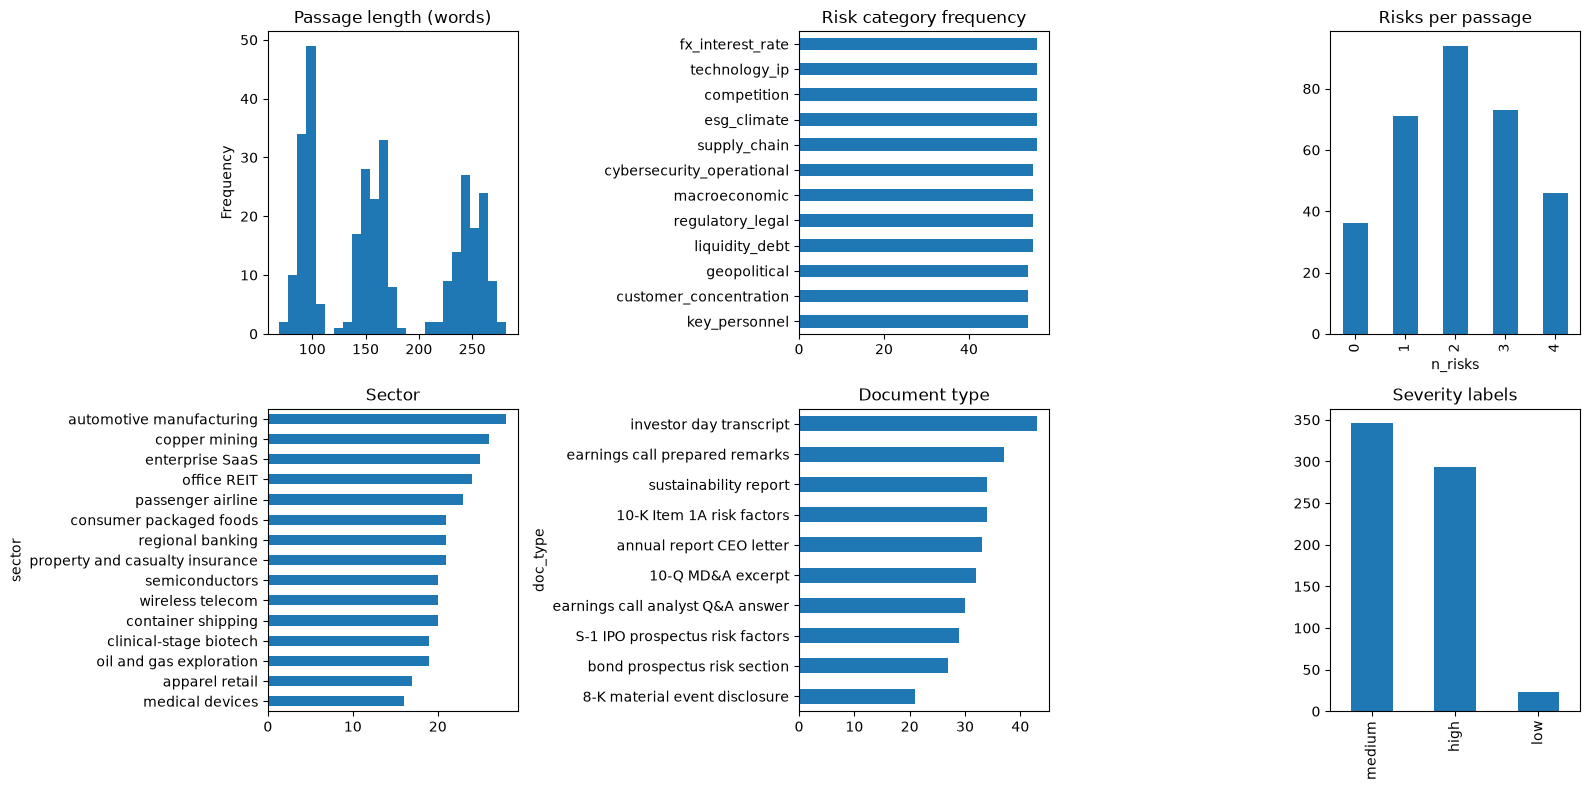

In [9]:
import matplotlib.pyplot as plt
frame = summary_frame(clean)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
frame["words"].plot.hist(bins=25, ax=axes[0, 0], title="Passage length (words)")
pd.Series(report["category_counts"]).sort_values().plot.barh(ax=axes[0, 1], title="Risk category frequency")
frame["n_risks"].value_counts().sort_index().plot.bar(ax=axes[0, 2], title="Risks per passage")
frame["sector"].value_counts().sort_values().plot.barh(ax=axes[1, 0], title="Sector")
frame["doc_type"].value_counts().sort_values().plot.barh(ax=axes[1, 1], title="Document type")
pd.Series(report["severity_counts"]).plot.bar(ax=axes[1, 2], title="Severity labels")
plt.tight_layout(); plt.show()

prompt+answer token lengths (Qwen tokenizer): {'min': 467, 'p50': 682, 'p95': 882, 'max': 950, 'suggested_max_seq_length': 960}


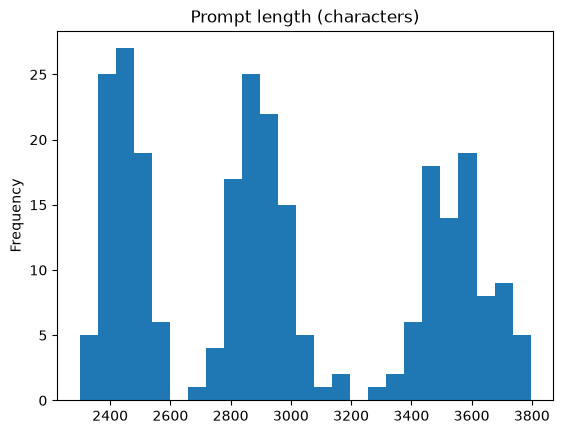

In [10]:
from task2_genai.finetune import token_length_stats
tok_stats = token_length_stats(tokenizer, train)
print("prompt+answer token lengths (Qwen tokenizer):", tok_stats)
lengths = [len(tokenizer.apply_chat_template(r["messages"][:-1], tokenize=False, add_generation_prompt=True)) for r in train]
pd.Series(lengths).plot.hist(bins=25, title="Prompt length (characters)"); plt.show()

In [11]:
pd.DataFrame(report["top_keywords"], columns=["keyword (TF-IDF, 1-2 grams)", "score"])

,"keyword (TF-IDF, 1-2 grams)",score
0,significant,4.96
1,remains,4.90
2,current,4.75
3,year,4.71
4,fiscal,4.70
5,term,4.47
6,furthermore,4.41
7,capital,4.38
8,primary,4.38
9,market,4.38


**Reading the diversity metrics.** Mean pairwise TF-IDF cosine close to 0 and a low p95 indicate passages are not minor variations of one scenario; distinct-2 measures lexical variety; near-duplicates above 0.85 cosine were removed before splitting so no test passage has a twin in training.